In [1]:
%matplotlib inline
import os 
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
class Args:
    def __init__(self):
        self.gpu = '0'
        self.resume = None
        self.dataset = 'Domain1'
        self.model = 'Deeplab'
        self.batch_size = 2
        self.group_num = 1
        self.max_epoch = 200
        self.stop_epoch = 200
        self.warmup_epoch = -1
        self.interval_validate = 5
        self.interval_save = 10
        self.lr = 1e-3
        self.lr_decrease_rate = 0.98
        self.lr_decrease_epoch = 1
        self.weight_decay = 0
        self.momentum = 0.99
        # self.data_dir = './Fundus'
        self.out_stride = 16
        self.sync_bn = True
        self.freeze_bn = False
        self.no_augmentation = False  # This is how you handle `store_true` action. Default to False.
        self.method = 'CCSDG'
        self.expid = 'OVERLEAF'

args = Args()
from datetime import datetime
import os
os.environ['CUDA_VISIBLE_DEVICES'] = args.gpu
import os.path as osp

# PyTorch includes
import torch
from torchvision import transforms
from torch.utils.data import DataLoader
import yaml
#from train_process import Trainer
from medpy.metric import binary
# Custom includes
from dataloaders import fundus_dataloader
from dataloaders import custom_transforms as trans
from utils.prostae_utils import postprocessing, _connectivity_region_analysis
from networks.deeplabv3 import *

In [2]:
import os
import random
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

class Prostate(Dataset):
    def __init__(self, domain_indices=None, base_dir=None, split='train', num=None, transform=None, seed=42):
        self.base_dir = base_dir
        self.num = num
        self.domain_name = ['Domain1', 'Domain2', 'Domain3', 'Domain4', 'Domain5', 'Domain6']
        self.domain_indices = domain_indices if domain_indices is not None else [0]
        self.split = split
        self.transform = transform  # Now expects a transform
        self.seed = seed  # seed for random operations to ensure reproducibility

        # Set random seed for reproducibility
        random.seed(self.seed)
        np.random.seed(self.seed)

        # Load image IDs from all specified domains
        self.id_path = []
        for domain_idx in self.domain_indices:
            full_id_path = os.listdir(os.path.join(self.base_dir, self.domain_name[domain_idx], 'image'))
            if self.num is not None:
                full_id_path = full_id_path[:self.num]
            
            # Shuffle and split data
            random.shuffle(full_id_path)
            split_idx = int(0.9 * len(full_id_path))  # 90% for training
            if self.split == 'train':
                self.id_path.extend([(domain_idx, id) for id in full_id_path[:split_idx]])
            elif self.split == 'test':
                self.id_path.extend([(domain_idx, id) for id in full_id_path[split_idx:]])
            elif self.split == 'full':
                self.id_path.extend([(domain_idx, id) for id in full_id_path])
        
        print("total {} samples for {}".format(len(self.id_path), self.split))
    
    def __len__(self):
        return len(self.id_path)
    
    def __getitem__(self, index):
        domain_idx, id = self.id_path[index]
        img = np.load(os.path.join(self.base_dir, self.domain_name[domain_idx], 'image', id))
        mask = np.load(os.path.join(self.base_dir, self.domain_name[domain_idx], 'mask', id))
        
        img = img.transpose(2, 0, 1)
        img = torch.from_numpy(img).float()  # img torch.Size([3, 384, 384])
        mask = torch.from_numpy(mask).float()  # gt torch.Size([384, 384])
        mask = mask.unsqueeze(0)
        
        sample = {'image': img, 'label': mask, 'img_name': id}

        if self.transform:
            sample = self.transform(sample)
        
        return sample['image'],sample['label'],sample['img_name']

# Define a transform if needed
train_transform = None

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)



In [ ]:
import os
def find_pth_tar_files(directory):
    pth_tar_files = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.endswith(".pth.tar"):
                pth_tar_files.append(os.path.join(root, file))
    return pth_tar_files
directory_path = '../autodl-fs'  
pth_tar_files = find_pth_tar_files(directory_path)
for file_path in pth_tar_files:
    print(file_path)

In [4]:
# import os
# import random
# import numpy as np
# from PIL import Image
# import torch
# from torch.utils.data import Dataset, DataLoader

# class Prostate(Dataset):
#     def __init__(self, domain_indices=None, base_dir=None, split='train', num=None, transform=None, seed=42):
#         self.base_dir = base_dir
#         self.num = num
#         self.domain_name = ['Domain1', 'Domain2', 'Domain3', 'Domain4', 'Domain5', 'Domain6']
#         self.domain_indices = domain_indices if domain_indices is not None else [0]
#         self.split = split
#         self.transform = transform  # Now expects a transform
#         self.seed = seed  # seed for random operations to ensure reproducibility

#         # Set random seed for reproducibility
#         random.seed(self.seed)
#         np.random.seed(self.seed)

#         # Load image IDs from all specified domains
#         self.id_path = []
#         for domain_idx in self.domain_indices:
#             full_id_path = os.listdir(os.path.join(self.base_dir, self.domain_name[domain_idx], 'image'))
#             if self.num is not None:
#                 full_id_path = full_id_path[:self.num]
            
#             # Shuffle and split data
#             random.shuffle(full_id_path)
#             split_idx = int(0.9 * len(full_id_path))  # 90% for training
#             if self.split == 'train':
#                 self.id_path.extend([(domain_idx, id) for id in full_id_path[:split_idx]])
#             elif self.split == 'test':
#                 self.id_path.extend([(domain_idx, id) for id in full_id_path[split_idx:]])
#             elif self.split == 'full':
#                 self.id_path.extend([(domain_idx, id) for id in full_id_path])
        
#         print("total {} samples for {}".format(len(self.id_path), self.split))
    
#     def __len__(self):
#         return len(self.id_path)
    
#     def __getitem__(self, index):
#         domain_idx, id = self.id_path[index]
#         img = np.load(os.path.join(self.base_dir, self.domain_name[domain_idx], 'image', id))
#         mask = np.load(os.path.join(self.base_dir, self.domain_name[domain_idx], 'mask', id))
        
#         img = img.transpose(2, 0, 1)
#         img = torch.from_numpy(img).float()  # img torch.Size([3, 384, 384])
#         mask = torch.from_numpy(mask).float()  # gt torch.Size([384, 384])
#         mask = mask.unsqueeze(0)
        
#         sample = {'image': img, 'label': mask, 'img_name': id}

#         if self.transform:
#             sample = self.transform(sample)
        
#         return sample

# # Define a transform if needed
# train_transform = None

# def seed_worker(worker_id):
#     worker_seed = torch.initial_seed() % 2**32
#     np.random.seed(worker_seed)
#     random.seed(worker_seed)



In [5]:
# import torch
# import os.path as osp
# modelSelect = 5
# from utils.transform import collate_fn_tr_styleaug, collate_fn_ts

# #CCSDG
# if modelSelect == 1: 
#     checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain6/CCSDG/20240729_171122/checkpoint_199.pth.tar')
#     checkpoint = torch.load(checkpoint_path)
#     model = DeepLab(num_classes=1, backbone='CCSDG', output_stride=args.out_stride,sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)
# #SLAUG
# elif modelSelect == 2:
#     checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain6/SLAUG/20240729_200230/checkpoint_199.pth.tar')
#     checkpoint = torch.load(checkpoint_path)
#     model = DeepLab(num_classes=1, backbone='mobilenet', output_stride=args.out_stride,sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)
# #CISDG
# elif modelSelect == 3:
#     checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain6/CISDG/20240729_183953/checkpoint_199.pth.tar')
#     checkpoint = torch.load(checkpoint_path)
#     model = DeepLab(num_classes=1, backbone='mobilenet', output_stride=args.out_stride,sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)
    
# #ADA
# elif modelSelect == 4:
#     checkpoint_path = osp.join('../autodl-fs/Prostate-004_checkpoint_199.pth.tar')
#     checkpoint = torch.load(checkpoint_path)
#     model = DeepLab(num_classes=1, backbone='ADA', output_stride=args.out_stride,sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)
# #mobilenet
# elif modelSelect == 5:
#     checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain6/mobilenet/20240729_232751/checkpoint_199.pth.tar')
#     checkpoint = torch.load(checkpoint_path)
#     model = DeepLab(num_classes=1, backbone='mobilenet', output_stride=args.out_stride,sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)

    
    
# model.load_state_dict(checkpoint['model_state_dict'])
# model = model.cuda()
# import torch
# import numpy as np
# import torch.nn.functional as F
# def dice_coeff(pred, target):
#     smooth = 1e-5
#     intersection = (pred * target).sum()
#     union = pred.sum() + target.sum()
#     dice = (2. * intersection + smooth) / (union + smooth)
#     return dice

# def iou_coeff(pred, target):
#     smooth = 1e-5
#     intersection = (pred * target).sum()
#     union = pred.sum() + target.sum() - intersection
#     iou = (intersection + smooth) / (union + smooth)
#     return iou

# def validate_prostate(val_loader=None):
#     model.eval()

#     val_loss = 0.0
#     total_dice = 0.0
#     total_iou = 0.0
#     data_num_cnt = 0

#     all_predictions = []
#     all_targets = []
#     all_scores = []

#     with torch.no_grad():
#         for batch_idx, sample in enumerate(val_loader):
            
#             data = sample['image'].cuda().to(dtype=torch.float32)
#             target_map = sample['label'].cuda().to(dtype=torch.float32)

#             if args.method == "RSC" or args.method == "ADA":
#                 predictions, _ = model(data, None, None)
#             else:
#                 predictions, _ = model(data)

#             loss = F.binary_cross_entropy_with_logits(predictions, target_map)
#             loss_data = loss.item()
#             if np.isnan(loss_data):
#                 raise ValueError('loss is nan while validating')
#             val_loss += loss_data

#             #pred = torch.sigmoid(predictions)
#             pred = predictions
#             pred[pred > 0.75] = 1
#             pred[pred <= 0.75] = 0

#             dice_score = dice_coeff(pred, target_map)
#             total_dice += dice_score.item()

#             iou_score = iou_coeff(pred, target_map)
#             total_iou += iou_score.item()

#             data_num_cnt += 1

#             # Save predictions, ground truth, and scores to lists
#             all_predictions.append(pred.cpu().numpy())
#             all_targets.append(target_map.cpu().numpy())
#             all_scores.append( dice_score.item())

#         avg_loss = val_loss / data_num_cnt
#         avg_dice = total_dice / data_num_cnt
#         avg_iou = total_iou / data_num_cnt

#         print(f'Dice: {avg_dice:.4f}')
#         print(f'IoU: {avg_iou:.4f}')

#         return all_predictions, all_targets, all_scores

# test_transform =None
# testset = Prostate(domain_indices=[0],base_dir='./dataset/prostate', split='test', transform=test_transform)

# testloader = DataLoader(testset, batch_size=8, num_workers=0,
#                      shuffle=False, drop_last=False, pin_memory=True, worker_init_fn=seed_worker)

# testset2 = Prostate(domain_indices=[1],base_dir='./dataset/prostate', split='test', transform=test_transform)

# testloader2 = DataLoader(testset2, batch_size=8, num_workers=0,
#                      shuffle=False, drop_last=False, pin_memory=True, worker_init_fn=seed_worker)

# testset3 = Prostate(domain_indices=[2], base_dir='./dataset/prostate', split='test', transform=test_transform)

# testloader3 = DataLoader(testset3, batch_size=8, num_workers=0,
#                      shuffle=False, drop_last=False, pin_memory=True, worker_init_fn=seed_worker)

# testset4 = Prostate(domain_indices=[3],base_dir='./dataset/prostate', split='test', transform=test_transform)

# testloader4 = DataLoader(testset4, batch_size=8, num_workers=0,
#                      shuffle=False, drop_last=False, pin_memory=True, worker_init_fn=seed_worker)

# testset5 = Prostate(domain_indices=[4],base_dir='./dataset/prostate', split='test', transform=test_transform)

# testloader5 = DataLoader(testset5, batch_size=8, num_workers=0,
#                      shuffle=False, drop_last=False, pin_memory=True, worker_init_fn=seed_worker)

# testset6 = Prostate(domain_indices=[5],base_dir='./dataset/prostate', split='full', transform=test_transform)

# testloader6 = DataLoader(testset6, batch_size=8, num_workers=0,
#                      shuffle=False, drop_last=False, pin_memory=True, worker_init_fn=seed_worker)

# print(f'-----Dataset: {args.dataset}--------')
# all_predictions1, all_targets1, all_scores1 =validate_prostate(val_loader=testloader)
# all_predictions2, all_targets2, all_scores2 =validate_prostate(val_loader=testloader2)
# all_predictions3, all_targets3, all_scores3 =validate_prostate(val_loader=testloader3)
# all_predictions4, all_targets4, all_scores4 =validate_prostate(val_loader=testloader4)
# all_predictions5, all_targets5, all_scores5 =validate_prostate(val_loader=testloader5)
# all_predictions6, all_targets6, all_scores6 =validate_prostate(val_loader=testloader6)
# print(f'-----Dataset: {args.dataset}--------')

In [3]:
import os
import random
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

class Prostate(Dataset):
    def __init__(self, domain_indices=None, base_dir=None, split='train', num=None, transform=None, seed=42):
        self.base_dir = base_dir
        self.num = num
        self.domain_name = ['Domain1', 'Domain2', 'Domain3', 'Domain4', 'Domain5', 'Domain6']
        self.domain_indices = domain_indices if domain_indices is not None else [0]
        self.split = split
        self.transform = transform  # Now expects a transform
        self.seed = seed  # seed for random operations to ensure reproducibility

        # Set random seed for reproducibility
        random.seed(self.seed)
        np.random.seed(self.seed)

        # Load image IDs from all specified domains
        self.id_path = []
        for domain_idx in self.domain_indices:
            full_id_path = os.listdir(os.path.join(self.base_dir, self.domain_name[domain_idx], 'image'))
            if self.num is not None:
                full_id_path = full_id_path[:self.num]
            
            # Shuffle and split data
            random.shuffle(full_id_path)
            split_idx = int(0.9 * len(full_id_path))  # 90% for training
            if self.split == 'train':
                self.id_path.extend([(domain_idx, id) for id in full_id_path[:split_idx]])
            elif self.split == 'test':
                self.id_path.extend([(domain_idx, id) for id in full_id_path[split_idx:]])
            elif self.split == 'full':
                self.id_path.extend([(domain_idx, id) for id in full_id_path])
        
        print("total {} samples for {}".format(len(self.id_path), self.split))
    
    def __len__(self):
        return len(self.id_path)
    
    def __getitem__(self, index):
        domain_idx, id = self.id_path[index]
        img = np.load(os.path.join(self.base_dir, self.domain_name[domain_idx], 'image', id))
        mask = np.load(os.path.join(self.base_dir, self.domain_name[domain_idx], 'mask', id))
        
        img = img.transpose(2, 0, 1)
        img = torch.from_numpy(img).float()  # img torch.Size([3, 384, 384])
        mask = torch.from_numpy(mask).float()  # gt torch.Size([384, 384])
        mask = mask.unsqueeze(0)
        
        sample = {'image': img, 'label': mask, 'img_name': id}

        if self.transform:
            sample = self.transform(sample)
        
        return sample['image'],sample['label'],sample['img_name']

# Define a transform if needed
train_transform = None

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)



In [25]:
import torch
import os.path as osp
import shutil

def load_and_save_model(modelSelect, save_dir):
    # 确保保存目录存在
    if not osp.exists(save_dir):
        os.makedirs(save_dir)
    #CCSDG
    if modelSelect == 1: 
        checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain4/CCSDG/20240731_032203/checkpoint_199.pth.tar')
        checkpoint = torch.load(checkpoint_path)
        model = DeepLab(num_classes=1, backbone='CCSDG', output_stride=args.out_stride,sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)
        new_checkpoint_path = osp.join(save_dir, 'CCSDG_checkpoint_199.pth.tar')
    #SLAUG
    elif modelSelect == 2:
        checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain4/SLAUG/20240731_072449/checkpoint_199.pth.tar')
        checkpoint = torch.load(checkpoint_path)
        new_checkpoint_path = osp.join(save_dir, 'SLAUG_checkpoint_200.pth.tar')
        model = DeepLab(num_classes=1, backbone='mobilenet', output_stride=args.out_stride,sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)
    #CISDG
    elif modelSelect == 3:
        checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain4/CISDG/20240731_054131/checkpoint_199.pth.tar')
        checkpoint = torch.load(checkpoint_path)
        new_checkpoint_path = osp.join(save_dir, 'CISDG_checkpoint_200.pth.tar')
        model = DeepLab(num_classes=1, backbone='mobilenet', output_stride=args.out_stride,sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)

    #ADA
    elif modelSelect == 4:
        checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain4/ADA/20240731_001402/checkpoint_199.pth.tar')
        checkpoint = torch.load(checkpoint_path)
        new_checkpoint_path = osp.join(save_dir, 'ADA_checkpoint_200.pth.tar')
        model = DeepLab(num_classes=1, backbone='ADA', output_stride=args.out_stride,sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)
    #mobilenet
    elif modelSelect == 5:
        checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain4/mobilenet/20240731_020726/checkpoint_199.pth.tar')
        checkpoint = torch.load(checkpoint_path)
        model = DeepLab(num_classes=1, backbone='mobilenet', output_stride=args.out_stride,sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)
        new_checkpoint_path = osp.join(save_dir, 'mobilenet_checkpoint_199.pth.tar')
        #RSC
    elif modelSelect == 6:
        checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain4/RSC/20240731_063411/checkpoint_185.pth.tar')
        checkpoint = torch.load(checkpoint_path)
        new_checkpoint_path = osp.join(save_dir, 'RSC_checkpoint_200.pth.tar')
        model = DeepLab(num_classes=1, backbone='mobilenet', output_stride=args.out_stride,sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)
        
    # 加载权重
    checkpoint = torch.load(checkpoint_path)
    # 保存权重到新的路径
    torch.save(checkpoint, new_checkpoint_path)
    print(f"Saved model {modelSelect} weights to {new_checkpoint_path}")

# 示例用法
save_directory = '../autodl-fs/ProstateSelectWeight'
# for model_select in range(1, 7):
load_and_save_model(1, save_directory)
load_and_save_model(3, save_directory)
load_and_save_model(4, save_directory)
load_and_save_model(5, save_directory)
load_and_save_model(6, save_directory)

Saved model 1 weights to ../autodl-fs/ProstateSelectWeight/CCSDG_checkpoint_199.pth.tar
Saved model 3 weights to ../autodl-fs/ProstateSelectWeight/CISDG_checkpoint_200.pth.tar
Saved model 4 weights to ../autodl-fs/ProstateSelectWeight/ADA_checkpoint_200.pth.tar
Saved model 5 weights to ../autodl-fs/ProstateSelectWeight/mobilenet_checkpoint_199.pth.tar
Saved model 6 weights to ../autodl-fs/ProstateSelectWeight/RSC_checkpoint_200.pth.tar


In [7]:
import torch
import os.path as osp
modelSelect = 4
from utils.transform import collate_fn_tr_styleaug, collate_fn_ts

#CCSDG
if modelSelect == 1: 
    #checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain6/CCSDG/20240730_074607/checkpoint_195.pth.tar')
    checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain4/CCSDG/20240731_032203/checkpoint_199.pth.tar')
    
    checkpoint = torch.load(checkpoint_path)
    model = DeepLab(num_classes=1, backbone='CCSDG', output_stride=args.out_stride,sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)
#SLAUG
elif modelSelect == 2:
    checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain6/SLAUG/20240730_103403/checkpoint_199.pth.tar')
    checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain6/SLAUG/20240730_202114/checkpoint_199.pth.tar')
    
    checkpoint = torch.load(checkpoint_path)
    model = DeepLab(num_classes=1, backbone='mobilenet', output_stride=args.out_stride,sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)
#CISDG
elif modelSelect == 3:
    checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain4/CISDG/20240811_154755/checkpoint_170.pth.tar')
    checkpoint = torch.load(checkpoint_path)
    model = DeepLab(num_classes=1, backbone='mobilenet', output_stride=args.out_stride,sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)
    
#ADA
elif modelSelect == 4:
    
    checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain4/ADA/20240811_161321/checkpoint_160.pth.tar')
    #checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain4/ADA/20240811_130246/checkpoint_199.pth.tar')
    #checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain4/ADA/20240811_135440/checkpoint_199.pth.tar')
    
    checkpoint = torch.load(checkpoint_path)
    model = DeepLab(num_classes=1, backbone='ADA', output_stride=args.out_stride,sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)
#mobilenet
elif modelSelect == 5:
    checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain4/mobilenet/20240731_020726/checkpoint_199.pth.tar')
    #checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain4/mobilenet/20240731_071513/checkpoint_199.pth.tar')
    
    checkpoint = torch.load(checkpoint_path)
    model = DeepLab(num_classes=1, backbone='mobilenet', output_stride=args.out_stride,sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)

#RSC
elif modelSelect == 6:
    checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain6/RSC/20240730_002840/checkpoint_100.pth.tar')
    checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain4/RSC/20240731_063411/checkpoint_185.pth.tar')

    checkpoint = torch.load(checkpoint_path)
    model = DeepLab(num_classes=1, backbone='mobilenet', output_stride=args.out_stride,sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)

elif modelSelect == 7:
    checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain6/RSC/20240730_002840/checkpoint_100.pth.tar')
    checkpoint_path = osp.join('./logs_train/Visualization/Prostate/Domain6/Ranconv/20240730_163134/checkpoint_100.pth.tar')

    checkpoint = torch.load(checkpoint_path)
    model = DeepLab(num_classes=1, backbone='mobilenet', output_stride=args.out_stride,sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)
    
model.load_state_dict(checkpoint['model_state_dict'])
model = model.cuda()
import torch
import numpy as np
import torch.nn.functional as F
def dice_coeff(pred, target):
    smooth = 1e-5
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice

def iou_coeff(pred, target):
    smooth = 1e-5
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou

def validate_prostate(val_loader=None):
    model.eval()

    val_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    data_num_cnt = 0

    all_predictions = []
    all_targets = []
    all_scores = []

    with torch.no_grad():
        for batch_idx, sample in enumerate(val_loader):
            
            data = torch.from_numpy(sample['data']).cuda().to(dtype=torch.float32)
            target_map = torch.from_numpy(sample['seg']).cuda().to(dtype=torch.float32)

            if args.method == "RSC" or args.method == "ADA":
                predictions, _ = model(data, None, None)
            else:
                predictions, _ = model(data)

            loss = F.binary_cross_entropy_with_logits(predictions, target_map)
            loss_data = loss.item()
            if np.isnan(loss_data):
                raise ValueError('loss is nan while validating')
            val_loss += loss_data

            pred = torch.sigmoid(predictions)
            pred = predictions
            pred[pred > 0.75] = 1
            pred[pred <= 0.75] = 0

            dice_score = dice_coeff(pred, target_map)
            total_dice += dice_score.item()

            iou_score = iou_coeff(pred, target_map)
            total_iou += iou_score.item()

            data_num_cnt += 1

            # Save predictions, ground truth, and scores to lists
            all_predictions.append(pred.cpu().numpy())
            all_targets.append(target_map.cpu().numpy())
            all_scores.append( dice_score.item())

        avg_loss = val_loss / data_num_cnt
        avg_dice = total_dice / data_num_cnt
        avg_iou = total_iou / data_num_cnt

        print(f'Dice: {avg_dice:.4f}')
        print(f'IoU: {avg_iou:.4f}')

        return all_predictions, all_targets, all_scores

test_transform =None
split_select = 'full'
testset = Prostate(domain_indices=[0], base_dir='./dataset/prostate', split=split_select, transform=test_transform)

testloader = DataLoader(testset, batch_size=8, num_workers=0,
                        shuffle=False, drop_last=False, pin_memory=True, worker_init_fn=seed_worker, collate_fn=collate_fn_ts)

testset2 = Prostate(domain_indices=[1], base_dir='./dataset/prostate', split=split_select, transform=test_transform)

testloader2 = DataLoader(testset2, batch_size=8, num_workers=0,
                         shuffle=False, drop_last=False, pin_memory=True, worker_init_fn=seed_worker, collate_fn=collate_fn_ts)

testset3 = Prostate(domain_indices=[2], base_dir='./dataset/prostate', split=split_select, transform=test_transform)

testloader3 = DataLoader(testset3, batch_size=8, num_workers=0,
                         shuffle=False, drop_last=False, pin_memory=True, worker_init_fn=seed_worker, collate_fn=collate_fn_ts)

testset4 = Prostate(domain_indices=[3], base_dir='./dataset/prostate', split=split_select, transform=test_transform)

testloader4 = DataLoader(testset4, batch_size=8, num_workers=0,
                         shuffle=False, drop_last=False, pin_memory=True, worker_init_fn=seed_worker, collate_fn=collate_fn_ts)

testset5 = Prostate(domain_indices=[4], base_dir='./dataset/prostate', split=split_select, transform=test_transform)

testloader5 = DataLoader(testset5, batch_size=8, num_workers=0,
                         shuffle=False, drop_last=False, pin_memory=True, worker_init_fn=seed_worker, collate_fn=collate_fn_ts)

testset6 = Prostate(domain_indices=[5], base_dir='./dataset/prostate', split=split_select, transform=test_transform)

testloader6 = DataLoader(testset6, batch_size=8, num_workers=0,
                         shuffle=False, drop_last=False, pin_memory=True, worker_init_fn=seed_worker, collate_fn=collate_fn_ts)

print(f'-----Dataset: {args.dataset}--------')
all_predictions1, all_targets1, all_scores1 =validate_prostate(val_loader=testloader)
all_predictions2, all_targets2, all_scores2 =validate_prostate(val_loader=testloader2)
all_predictions3, all_targets3, all_scores3 =validate_prostate(val_loader=testloader3)
all_predictions4, all_targets4, all_scores4 =validate_prostate(val_loader=testloader4)
all_predictions5, all_targets5, all_scores5 =validate_prostate(val_loader=testloader5)
all_predictions6, all_targets6, all_scores6 =validate_prostate(val_loader=testloader6)
print(f'-----Dataset: {args.dataset}--------')

<All keys matched successfully>

total 387 samples for full
total 354 samples for full
total 449 samples for full
total 162 samples for full
total 249 samples for full
total 146 samples for full
-----Dataset: Domain1--------
Dice: 0.8411
IoU: 0.7308
Dice: 0.8870
IoU: 0.7979
Dice: 0.7412
IoU: 0.5919
Dice: 0.9475
IoU: 0.9004
Dice: 0.7456
IoU: 0.6030
Dice: 0.7927
IoU: 0.6622
-----Dataset: Domain1--------


total 45 samples for test


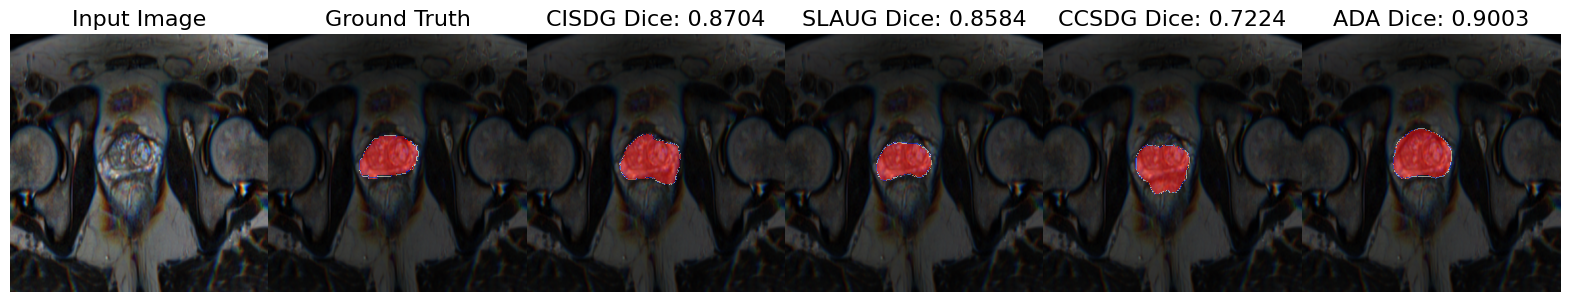

In [45]:
import torch
import os.path as osp
import matplotlib.pyplot as plt
import numpy as np
from utils.transform import collate_fn_tr_styleaug, collate_fn_ts

# Ensure inline plotting in Jupyter notebooks
%matplotlib inline

def load_model(modelSelect):
    if modelSelect == 1:
        checkpoint_path = osp.join('../autodl-fs/ProstateSelectWeight/CISDG_checkpoint_200.pth.tar')
        checkpoint = torch.load(checkpoint_path)
        model = DeepLab(num_classes=1, backbone='mobilenet', output_stride=args.out_stride, sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)
    elif modelSelect == 2:
        checkpoint_path = osp.join('../autodl-fs/ProstateSelectWeight/SLAUG_checkpoint_200.pth.tar')
        checkpoint = torch.load(checkpoint_path)
        model = DeepLab(num_classes=1, backbone='mobilenet', output_stride=args.out_stride, sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)
    elif modelSelect == 3:
        checkpoint_path = osp.join('../autodl-fs/ProstateSelectWeight/CCSDG_checkpoint_199.pth.tar')
        checkpoint = torch.load(checkpoint_path)
        model = DeepLab(num_classes=1, backbone='CCSDG', output_stride=args.out_stride, sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)
    elif modelSelect == 4:
        checkpoint_path = osp.join('../autodl-fs/ProstateSelectWeight/ADA_checkpoint_200.pth.tar')
        checkpoint = torch.load(checkpoint_path)
        model = DeepLab(num_classes=1, backbone='ADA', output_stride=args.out_stride, sync_bn=args.sync_bn, freeze_bn=args.freeze_bn)

    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.cuda()
    model.eval()
    return model

def predict_image(model, data):
    with torch.no_grad():
        predictions, _ = model(data)
        pred = torch.sigmoid(predictions)
        pred[pred > 0.75] = 1
        pred[pred <= 0.75] = 0
    return pred.cpu().numpy()

def dice_coeff(pred, target):
    smooth = 1e-5
    intersection = np.sum(pred * target)
    union = np.sum(pred) + np.sum(target)
    return (2. * intersection + smooth) / (union + smooth)

def visualize_results(data, target_map, predictions_list, model_names):
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, len(predictions_list) + 2, 1)
    plt.title('Input Image')
    plt.imshow(np.clip(data[0].cpu().numpy().transpose(1, 2, 0), 0, 1))  # Ensure values are in range [0, 1]
    
    plt.subplot(1, len(predictions_list) + 2, 2)
    plt.title('Ground Truth')
    gt_image = target_map[0].cpu().numpy().squeeze()
    if np.max(gt_image) == 0 and np.min(gt_image) == 0:
        plt.text(0.5, 0.5, 'No GT Data', horizontalalignment='center', verticalalignment='center')
    else:
        plt.imshow(gt_image, cmap='gray', vmin=0, vmax=1)
    
    for i, (pred, name) in enumerate(zip(predictions_list, model_names)):
        plt.subplot(1, len(predictions_list) + 2, i + 3)
        dice_score = dice_coeff(pred[0].squeeze(), gt_image)
        plt.title(f'{name} Dice: {dice_score:.4f}')
        pred_image = pred[0].squeeze()
        if np.max(pred_image) == 0 and np.min(pred_image) == 0:
            plt.text(0.5, 0.5, 'No Prediction', horizontalalignment='center', verticalalignment='center')
        else:
            plt.imshow(pred_image, cmap='gray', vmin=0, vmax=1)
    
    plt.show()
def visualize_results(data, target_map, predictions_list, model_names):
    plt.figure(figsize=(20, 5))
    
    # 输入图像
    plt.subplot(1, len(predictions_list) + 2, 1)
    plt.title('Input Image', fontsize=16)
    data[0] = (data[0] - data[0].min()) / (data[0].max() - data[0].min())  # Normalize to [0, 1]
    input_image = np.clip(data[0].cpu().numpy().transpose(1, 2, 0), 0, 1)
    plt.imshow(input_image)  # Ensure values are in range [0, 1]
    plt.axis('off')
    
    # Ground Truth
    plt.subplot(1, len(predictions_list) + 2, 2)
    plt.title('Ground Truth', fontsize=16)
    gt_image = target_map[0].cpu().numpy().squeeze()
    plt.imshow(input_image)
    plt.imshow(gt_image, cmap='flag_r', alpha=0.5, vmin=0, vmax=1)  # Overlay GT with transparency
    plt.axis('off')
    
    # 预测图像
    for i, (pred, name) in enumerate(zip(predictions_list, model_names)):
        plt.subplot(1, len(predictions_list) + 2, i + 3)
        pred_image = pred[0].squeeze()
        dice_score = dice_coeff(pred_image, gt_image)
        plt.title(f'{name} Dice: {dice_score:.4f}', fontsize=16)
        plt.imshow(input_image)
        plt.imshow(pred_image, cmap='flag_r', alpha=0.5, vmin=0, vmax=1)  # Overlay prediction with transparency
        plt.axis('off')

    plt.subplots_adjust(wspace=0, hspace=0)  # Minimize the gap between images
    plt.savefig('Prostate_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
# Load the image and ground truth (replace with your actual data loading mechanism)
test_transform = None
split_select = 'test'
testset = Prostate(domain_indices=[2], base_dir='./dataset/prostate', split=split_select, transform=test_transform)

testloader = DataLoader(testset, batch_size=8, num_workers=0,
                        shuffle=False, drop_last=False, pin_memory=True, worker_init_fn=seed_worker, collate_fn=collate_fn_ts)
# Specify the index of the sample you want to visualize
sample_index = 4  # Replace with the desired index

# Iterate through the DataLoader to reach the specific index
for idx, sample in enumerate(testloader):
    if idx == sample_index:
        break
data = torch.from_numpy(sample['data']).cuda().to(dtype=torch.float32)
target_map = torch.from_numpy(sample['seg']).cuda().to(dtype=torch.float32)

# Load models and predict
models = [1, 2, 3, 4]
model_names = ['CISDG', 'SLAUG', 'CCSDG','ADA']
predictions_list = []

for model_select in models:
    model = load_model(model_select)
    predictions = predict_image(model, data)
    predictions_list.append(predictions)

# Visualize results
visualize_results(data, target_map, predictions_list, model_names)
